In [1]:
import os
import yaml
import warnings
warnings.filterwarnings("ignore")

# Basic Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow Packages
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Dense, 
                               Input)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint)


# Image Dataset

#### Step 1: Loading train, valid, test images from the local directory

In [15]:
img_size = (224, 224)
batch_size = 32

# Train Image Dataset
train_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/train",
    labels = None,
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size, 
    shuffle = False, 
    seed = 42,
    verbose = True,
    batch_size = batch_size
)

# Valid Image Dataset
valid_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/val",
    labels = None, 
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size,
    shuffle = True,
    seed = 42, 
    verbose = True,
    batch_size = batch_size
)


# Test Image Dataset
test_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/test",
    labels = None, 
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size,
    shuffle = True,
    seed = 42, 
    verbose = True,
    batch_size = batch_size
)


Found 200 files.
Found 100 files.
Found 200 files.


In [16]:
# Normalize using a layer
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_img_dataset = train_img_dataset.map(lambda x: (normalization_layer(x)))
valid_img_dataset = valid_img_dataset.map(lambda x: (normalization_layer(x)))
test_img_dataset = test_img_dataset.map(lambda x: (normalization_layer(x)))


#### Step 2: View Train Sample Normalized Images

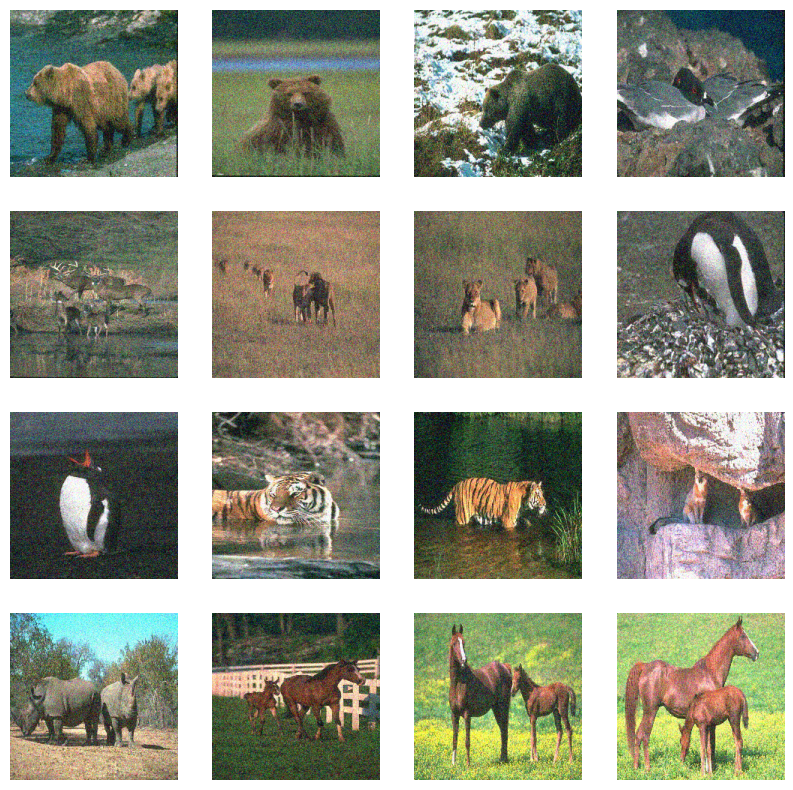

In [22]:
sample_batch = train_img_dataset.take(1)
for image in sample_batch:
    plt.figure(figsize= (10, 10))
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(image[i].numpy())
        plt.axis("off")
    break


#### Step 3: Adding Noise to the Images

In [19]:
def add_noise(image):
    """
        Adds noise to an image

        Args:
            image (numpy.ndarray) : The input image.

        Returns:
            numpy.ndarray: The image with noise added.
    """
    noise = np.random.normal(0, 0.1, image.shape)
    noisy_image = tf.clip_by_value(noise + image, 0, 1)
    return noisy_image

In [20]:
# Since each batch is a tensor of shape (batch_size, height, weight, channels),
# map_fn is used inside the .map() to apply preprocess_image to each image in the batch
train_img_dataset = train_img_dataset.map(
    lambda batch : tf.map_fn(add_noise, batch)
)

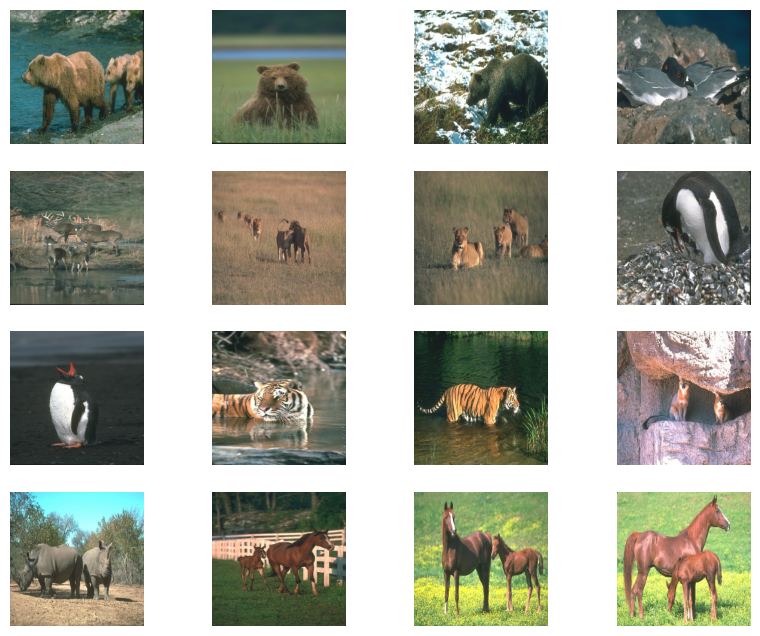

In [ ]:
sample_batch = train_img_dataset.take(1)
for image in sample_batch:
    plt.figure(figsize = (10, 8))
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(image[i])
        plt.axis("off")
    break
